# Laboratorium 10 - Warstwy Transformer


Na tym laboratorium zapoznamy się z warstwami Transformer i koncepcją hooks - funkcji, które jesteśmy w stanie "podłączyć" do istniejącego modelu na przejściowych warstwach przetwarzania.

Transformery to warstwy oparte o moduł uwagi. Koncepcja "uwagi" w sieciach głębokich to próba przetwarzania złożonych zależności w **zbiorach** obiektów - niekoniecznie sekwencjach, ale jest to jedno z typowych zastosowań.

Przykładowo, w przetwarzaniu zdania w języku naturalnym mamy problem ze złożonością naturalnej gramatyki, bo zależności niekoniecznie będą działały na zasadzie "każde słowo wpływa tylko na kolejne, następujące po nim słowo" (a wtedy nawięcej sensu miałoby działanie na zasadzie czystej rekurencji).

Zamiast tego, wykorzystanie uwagi oznacza, że przetwarzając słowo, możemy zwrócić **uwagę** na inne słowa **które są dla niego istotne**. Moduł uwagi musi się więc wyuczyć informacji o tym, które słowa są istotne dla siebie nawzajem. W najprostszej implementacji oznacza to porównywanie **każdego słowa z każdym**.

# Warstwa Transformer

Przyjrzyjmy się wewnętrznej strukturze warstwy Transformer:

In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn as nn
import torch.nn.functional as F
import math
from aeon.datasets import load_classification
from keras.src.datasets import imdb
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
from typing import Tuple
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
import torch._dynamo
torch._dynamo.config.suppress_errors = True

In [2]:
transformer = torch.nn.Transformer(d_model=10, nhead=1)

print(transformer)

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_features=10, bias=True)
        )
        (linear1): Linear(in_features=10, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=10, bias=True)
        (norm1): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_featu

C:\Users\48572\.conda\envs\deep_learning\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Ta implementacja podąża za oryginalną strukturą z *Attention is All You Need*, więc rozdziela enkodery i dekodery (ponieważ ta publikacja działała na problemie automatycznego tłumaczenia, gdzie potrzebna jest uwaga ze zdania wyjściowego na inne zdanie wejściowe), ma wiele dodatkowych operacji liniowych, LayerNorm, etc.

Sednem transformerów jest jednak operacja uwagi. Uwaga oparta o moduły self-attention (nazwę transformer w zasadzie mozna zastosować do dowolnych sieci opierających się o ten moduł) daje sieciom głębokim możliwość dopasowania do wielu typów danych w kórych zachodzą relacje między elementami: sekwencji (relacje w czasie), grafów (połączenia), obrazów (relacje pozycyjne w przestrzeni 2d), języka naturalnego (gramatyka) etc. Dzieje się tak, ponieważ bazowy mechanizm to po prostu porównanie każdy-z-każdym, a konkretną topologię problemu dodajemy przez inne mechanizmy, takie jak positional embedding i maskowanie.

# Zasada działania self-attention

Chcemy żeby każdy z elementów sekwencji "zapytał" (**query**) pozostałe elementy o to jak pozostałe elementy są **istotne dla niego**.

Aby to zapytanie miało sens, nasz element potrzebuje też jakiejś reprezentacji mówiącej relewantności dla innnych "pytających" elementów (**key**). W oparciu o to, możemy mnożąc macierze otrzymać macierz `liczba_elementów x liczba_elementów`. Następnie wykonamy na niej operację softmax. W ten sposób każdy element otrzymuj swoje "wagi uwagi" odnośnie wszystkich pozostałych elementów, które dzięki softmaxowi sumują się do jedynki.

Mając takie wagi, możemy zsumować reprezentacje pozostałych elementów wymnożone przez ich wagi. Ponieważ wynik tej operacji ma już iść dalej, a reprezentacje query i key służyły głównie do ustalania istotności elementów względem siebie nawzajem, stworzymy trzecią reprezentację elementów na potrzeby samego sumowania (**value**). W kodzie, dla uproszczenia bez batchowania danych:

In [3]:
sequence = torch.zeros((100,5))

query_projection = torch.nn.Linear(5,3)
key_projection = torch.nn.Linear(5,3)
value_projection = torch.nn.Linear(5,3)


q = query_projection(sequence)
k = key_projection(sequence)
v = value_projection(sequence)

attention = torch.nn.functional.softmax(q @ k.T, dim=-1)

print(attention.shape)

output = attention @ v

print(output.shape)

torch.Size([100, 100])
torch.Size([100, 3])


# Positional Embedding

O ile transformer osiągają imponujące wyniki w zadaniach sekwencyjnych, warto zwrócić uwagę, że zależności sekwencyjne nie są wbudowane w opisaną wyżej architekturę self-attention tak jak zależność, że krok n następuje po n-1 w sieciach rekurencyjnych, czy zależnoci pozycyjne w opercję konwolucji. Możemy wymusić, aby dla zadań predykcyjnych krok czasowy n nie widział króków n+1 i dalszych, ale sąsiedztwo w czasie w dalszym ciągu nie ma odzwierciedlenia w architekturze.

Istnieje bardzo proste rozwiązanie: dodajemy pozycję w sekwencji jako zmienną wejściową. Nie zawsze jest to reprezentacja dosłownie wyrażająca pozycje jako liczbę całkowitą - indeks, ale idea sprowadza się do dodania osadzenia pozycji wejściowej do naszych danych. Osadzenie można uzyskać z apomocą warstwy Mebedding, poznanej w poprzednim zadaniu.

Bardziej zaawansowane mechanizmy wykorzystują dodawanie informacji o pozycji na poziomie mechanizmu uwagi, modifikując wynik operacji mnożenia Q przez K, co pozwala uwzględnić informację o relatywnej pozycji.

## Zadanie 1

Przeprowadź trening sieci złożonej z trzech warstw TransformerEncoderLayer (w torch.nn) na zbiorach z poprzedniego zadania. Użyj jednej z opisanych wyżej wersji positional embedding. Dla klasyfikacji, dodaj osobny token na początku każdego zdania (tak aby sam w sobie nie był słowem).

$$\text{Scaled Attention Score} = \frac{Q \cdot K^T}{\sqrt{d_k}}$$
$$\text{Output} = \text{Softmax}(\text{Scaled Attention Score}) \cdot V$$

$$p_{i, 2j} = \sin\left(\frac{i}{10000^{2j/d}}\right),$$
$$p_{i, 2j+1} = \cos\left(\frac{i}{10000^{2j/d}}\right).$$

- https://www.geeksforgeeks.org/deep-learning/transformer-using-pytorch/
- https://medium.com/@kavierim/transformers-from-scratch-part-1-input-embeddings-positional-encoding-bbce1f39040d
- https://apxml.com/courses/foundations-transformers-architecture/chapter-3-multi-head-self-attention/practice-multi-head-attention-layer
- https://d2l.ai/chapter_attention-mechanisms-and-transformers/self-attention-and-positional-encoding.html
- https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/

In [4]:
# mieksce na kod - zimportuj zbiory z poprzedniego zadania i zastęp LSTM siecią z 3 warst TransformerEncoder z emebddingiem pozycji
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

X, y = load_classification("InsectWingbeat", extract_path="insect_data")

C:\Users\48572\AppData\Local\Temp\ipykernel_21228\2811043392.py:13: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y = load_classification("InsectWingbeat", extract_path="insect_data")


In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs = F.softmax(attn_scores, dim=-1)
        self.last_attn_probs = attn_probs
        output = torch.matmul(attn_probs, V)
        return output

    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor) -> torch.Tensor:
        batch_size = query.size(0)

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output = self.scaled_dot_product_attention(Q, K, V)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(attn_output)

        return output

In [6]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, 2*d_model)
        self.fc2 = nn.Linear(2*d_model, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        P_temp = torch.zeros((1, max_len, d_model))
        X = (torch.arange(max_len, dtype=torch.float32).reshape(-1, 1)
             / torch.pow(10000, torch.arange(0, d_model, 2, dtype=torch.float32) / d_model))
        P_temp[:, :, 0::2] = torch.sin(X)
        P_temp[:, :, 1::2] = torch.cos(X)

        self.register_buffer('P', P_temp)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :]
        return self.dropout(X)

In [8]:
class EncoderLayers(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [9]:
class IMDBTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=3, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, dropout)

        self.layers = nn.ModuleList([EncoderLayers(d_model, num_heads, dropout) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = self.positional_encoding(x)

        for layer in self.layers:
            x = layer(x)

        cls_token_final = x[:, 0, :]
        return self.classifier(cls_token_final)

In [15]:
import torch
import torch.nn as nn

class InsectTransformer(nn.Module):
    def __init__(self, d_model=64, num_heads=4, num_layers=3, dropout=0.1, num_classes=10, num_channels=11):
        super().__init__()

        self.input_projection = nn.Linear(num_channels, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)

        self.layers = nn.ModuleList([EncoderLayers(d_model, num_heads, dropout) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.positional_encoding(x)

        for layer in self.layers:
            x = layer(x)

        return self.classifier(x.mean(dim=1))

In [11]:
from typing import Union, List


class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_packed(batch):
    sample = batch[0][0]

    is_sequence_of_vectors = (
        isinstance(sample, np.ndarray) and sample.ndim == 2
    ) or (
        torch.is_tensor(sample) and sample.dim() == 2
    )

    if is_sequence_of_vectors:
        sequences = [torch.tensor(item[0], dtype=torch.float32) for item in batch]
    else:
        sequences = [torch.tensor(item[0], dtype=torch.long) for item in batch]

    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0
    )

    packed = pack_padded_sequence(
        padded,
        lengths.cpu(),
        batch_first=True,
        enforce_sorted=False
    )

    return packed, labels

def pad_features(x, target_features):
    seq_len, features = x.shape

    if features < target_features:
        pad_width = target_features - features

        padding = np.zeros((seq_len, pad_width), dtype=np.float32)

        x = np.concatenate([x, padding], axis=1)

    return x

def to_dataloader(
        X_train: Union[torch.Tensor, np.ndarray, List],
        y_train: Union[torch.Tensor, np.ndarray, List],
        X_test: Union[torch.Tensor, np.ndarray, List],
        y_test: Union[torch.Tensor, np.ndarray, List],
        batch_size: int = 32,
) -> Tuple[DataLoader, DataLoader]:
    train_ds = SequenceDataset(X_train, y_train)
    test_ds = SequenceDataset(X_test, y_test)

    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_packed,
        pin_memory=True
    )

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        collate_fn=collate_packed,
        pin_memory=True
    )

    return train_dl, test_dl

In [12]:
def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> tuple[float, float]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        if isinstance(X_batch, torch.nn.utils.rnn.PackedSequence):
            X_batch, _ = pad_packed_sequence(X_batch, batch_first=True)

        X_batch_cuda = X_batch.cuda()
        y_batch_cuda = y_batch.cuda()

        y_pred = model(X_batch_cuda)
        batch_size = len(y_pred)
        all += batch_size

        loss += loss_fn(y_pred, y_batch_cuda).item() * batch_size
        correct += count_correct(y_pred, y_batch_cuda)
    return loss / all, float(correct) / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True
):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  scaler = torch.amp.GradScaler('cuda')

  for epoch in range(epochs):
      model.train()
      for X_batch, y_batch in tqdm(train_dl):
            if isinstance(X_batch, torch.nn.utils.rnn.PackedSequence):
                X_batch, _ = pad_packed_sequence(X_batch, batch_first=True)

            X_batch_cuda = X_batch.cuda()
            y_batch_cuda = y_batch.cuda()

            with torch.amp.autocast(device_type='cuda'):
                y_pred = model(X_batch_cuda)
                loss = loss_fn(y_pred, y_batch_cuda)

            scaler.scale(loss).backward()

            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimiser)
            scaler.update()
            optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              history['train_loss'].append(train_loss)
              history['train_acc'].append(train_acc)
              history['val_loss'].append(val_loss)
              history['val_acc'].append(val_acc)
  return history

def plot_metrixes(all_histories):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    ax_train_loss = axes[0, 0]
    ax_val_loss = axes[0, 1]
    ax_train_acc = axes[1, 0]
    ax_val_acc = axes[1, 1]

    for name, hist in all_histories.items():
        train_loss = [float(x) for x in hist['train_loss']]
        val_loss = [float(x) for x in hist['val_loss']]
        train_acc = [float(x) for x in hist['train_acc']]
        val_acc = [float(x) for x in hist['val_acc']]

        ax_train_loss.plot(train_loss, label=name, linewidth=2)
        ax_val_loss.plot(val_loss, label=name, linewidth=2, linestyle='--')

        ax_train_acc.plot(train_acc, label=name, linewidth=2)
        ax_val_acc.plot(val_acc, label=name, linewidth=2, linestyle='--')

    ax_train_loss.set_title("Train Loss")
    ax_train_loss.set_xlabel("Epoch")
    ax_train_loss.set_ylabel("Loss")
    ax_train_loss.legend()
    ax_train_loss.grid(True, linestyle=':', alpha=0.6)

    ax_val_loss.set_title("Validation Loss")
    ax_val_loss.set_xlabel("Epoch")
    ax_val_loss.set_ylabel("Loss")
    ax_val_loss.legend()
    ax_val_loss.grid(True, linestyle=':', alpha=0.6)

    ax_train_acc.set_title("Train Accuracy")
    ax_train_acc.set_xlabel("Epoch")
    ax_train_acc.set_ylabel("Accuracy")
    ax_train_acc.legend()
    ax_train_acc.grid(True, linestyle=':', alpha=0.6)

    ax_val_acc.set_title("Validation Accuracy")
    ax_val_acc.set_xlabel("Epoch")
    ax_val_acc.set_ylabel("Accuracy")
    ax_val_acc.legend()
    ax_val_acc.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


IMDB


  0%|          | 0/1563 [00:00<?, ?it/s]W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125] WON'T CONVERT forward C:\Users\48572\AppData\Local\Temp\ipykernel_21228\701788606.py line 10 
W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125] due to: 
W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125] Traceback (most recent call last):
W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]   File "C:\Users\48572\.conda\envs\deep_learning\Lib\site-packages\torch\_dynamo\output_graph.py", line 1446, in _call_user_compiler
W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0524 17:52:11.913000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]   File "C:\Users\48572

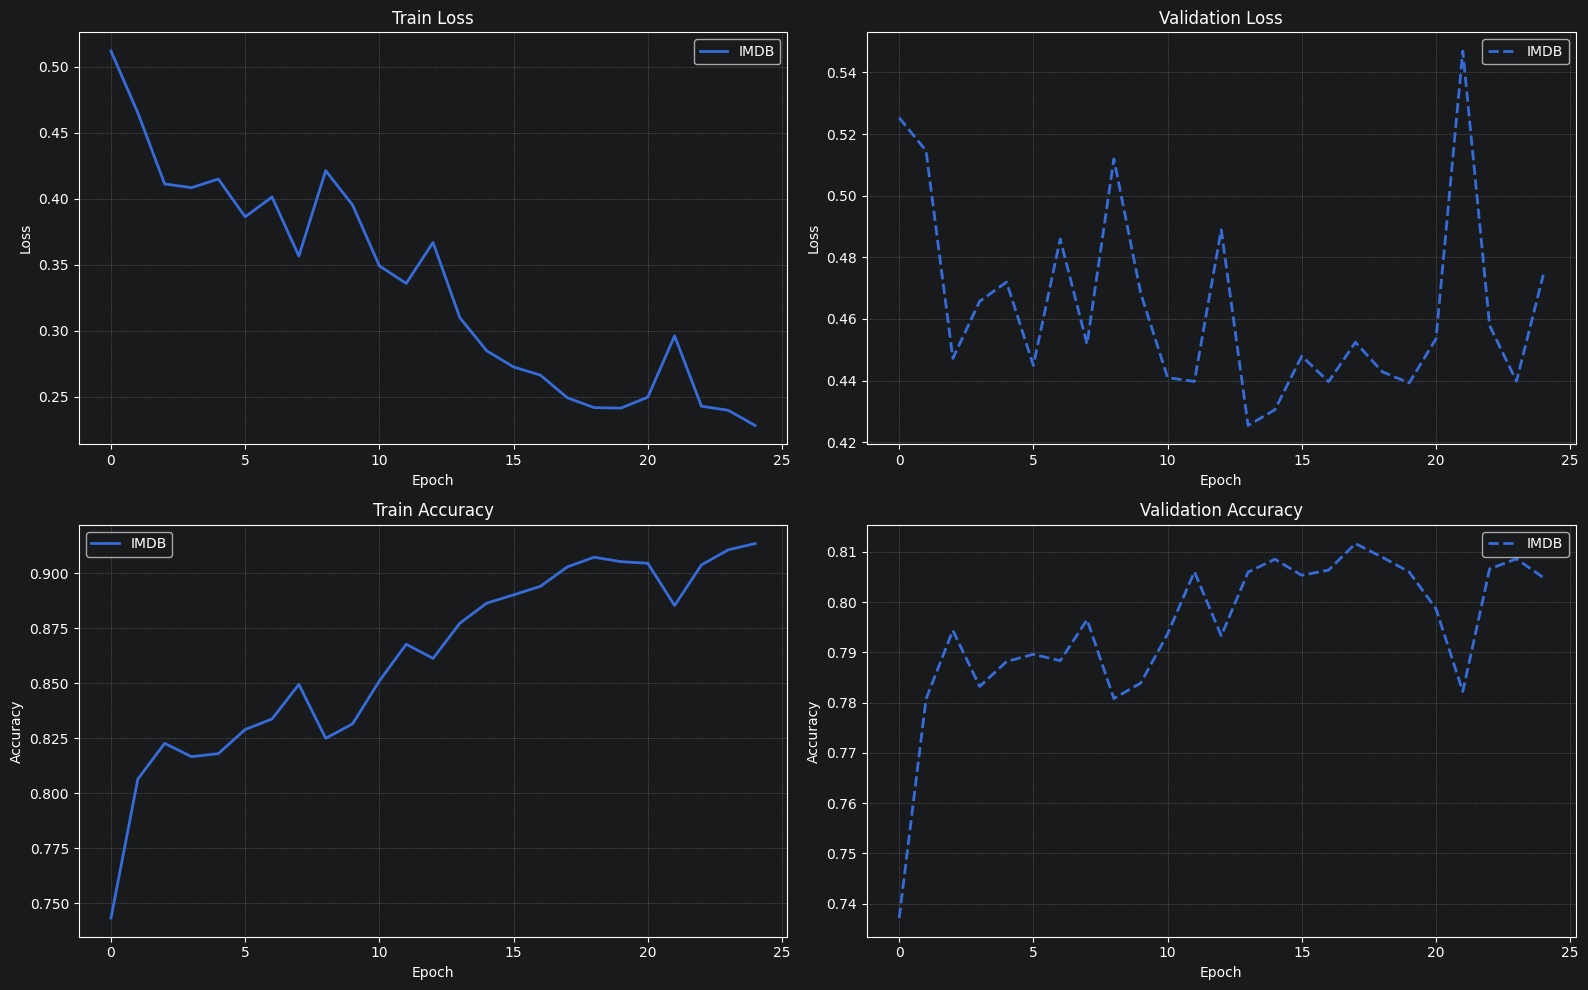

In [13]:
max_train_index = max([max(sequence) for sequence in x_train if len(sequence) > 0])
max_test_index = max([max(sequence) for sequence in x_test if len(sequence) > 0])
vocab_size = max(max_train_index, max_test_index) + 1

import numpy as np

if isinstance(y_train[0], str):
    unique_labels = sorted(list(set(y_train)))
    label_to_idx = {label: i for i, label in enumerate(unique_labels)}
    print(f"Wykryto etykiety tekstowe IMDB. Mapowanie: {label_to_idx}")

    y_train = [label_to_idx[label] for label in y_train]
    y_test = [label_to_idx[label] for label in y_test]

MAX_SEQ_LEN = 256
x_train_cls = [[0] + [t + 1 for t in seq][:MAX_SEQ_LEN-1] for seq in x_train]
x_test_cls = [[0] + [t + 1 for t in seq][:MAX_SEQ_LEN-1] for seq in x_test]

configs = {
    "IMDB": (
        IMDBTransformer(vocab_size=vocab_size, d_model=128, num_heads=4, num_layers=3)
    ),
}

all_histories = {}
torch.cuda.empty_cache()

for name, model in configs.items():
    print(f"\n{name}")
    model = model.cuda()
    model = torch.compile(model)

    loss = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_dl, test_dl = to_dataloader(x_train_cls, y_train, x_test_cls, y_test, batch_size=16)

    history = fit(model, optimizer, loss, train_dl, test_dl, epochs=25)
    all_histories[name] = history

plot_metrixes(all_histories)


InsectWingbeat


  0%|          | 0/625 [00:00<?, ?it/s]W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125] WON'T CONVERT forward C:\Users\48572\AppData\Local\Temp\ipykernel_21228\2284773110.py line 14 
W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125] due to: 
W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125] Traceback (most recent call last):
W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]   File "C:\Users\48572\.conda\envs\deep_learning\Lib\site-packages\torch\_dynamo\output_graph.py", line 1446, in _call_user_compiler
W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0524 19:03:02.082000 21228 site-packages\torch\_dynamo\convert_frame.py:1125]   File "C:\Users\48572

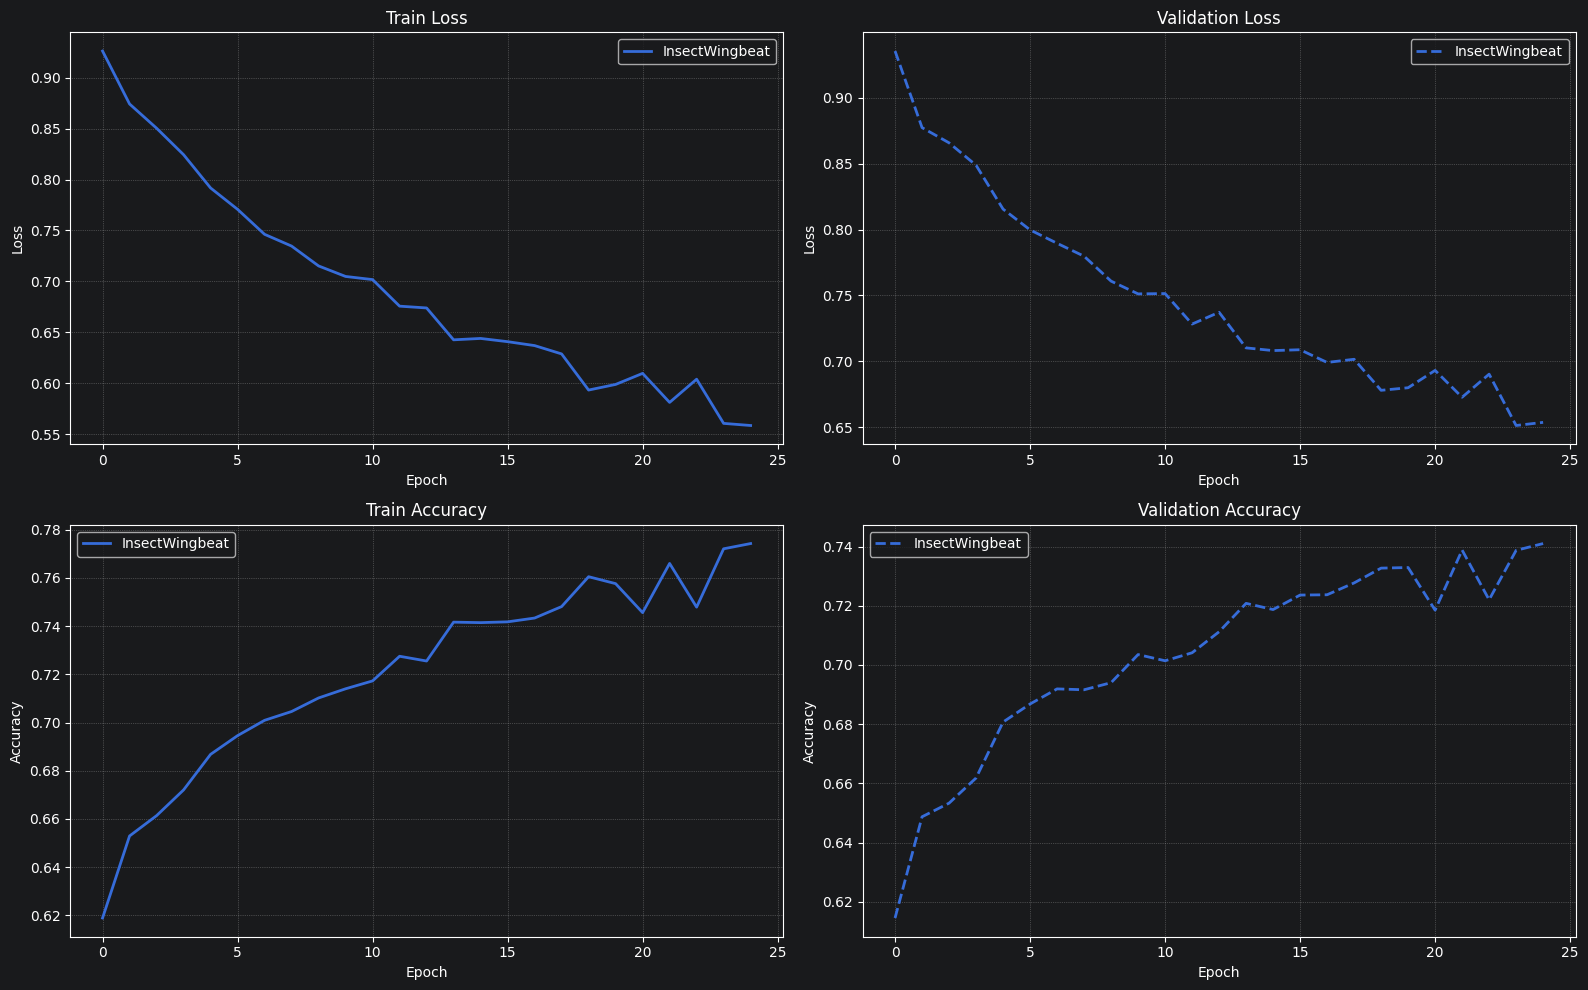

In [16]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

if isinstance(X, pd.DataFrame):
    X_processed = [np.stack([channel.values for channel in row]) for _, row in X.iterrows()]
elif isinstance(X, np.ndarray):
    X_processed = [X[i] for i in range(X.shape[0])]
elif isinstance(X, list):
    X_processed = [np.array(x, dtype=np.float32) for x in X]

max_features = max(sample.shape[1] for sample in X_processed)

X_processed = [
    pad_features(sample, max_features)
    for sample in X_processed
]
X_train_ins, X_test_ins, y_train_ins, y_test_ins = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=113
)
num_channels = max_features

configs = {
    "InsectWingbeat": InsectTransformer(
        num_channels=num_channels,
        d_model=64,
        num_heads=4,
        num_layers=3,
        num_classes=10
    )
}

all_histories = {}
torch.cuda.empty_cache()

for name, model in configs.items():
    print(f"\n{name}")
    model = model.cuda()
    model = torch.compile(model)

    loss = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_dl, test_dl = to_dataloader(X_train_ins, y_train_ins, X_test_ins, y_test_ins, batch_size=64)

    history = fit(model, optimizer, loss, train_dl, test_dl, epochs=25)
    all_histories[name] = history

plot_metrixes(all_histories)

## Pytorch hooks

Działając z głębokimi sieciami, często korzystać będziemy z gotowych modeli, a jeżeli chcielibyśmy spojrzeć na to, co dzieje się wewnątrz sieci, próba napisania od nowa własnego `forward` które weźmie to pod uwagę nie jest wygodnym rozwiązaniem.

Domyślna klasa reprezentująca warstwę w torchu, czyli `torch.nn.Module`, oferuje nam możliwość wstrzyknięcia własnego kodu zarówno w `forward`, jak i `backward` poprzez rejestrację hooków. Są to funkcje, które automatycznie wywołają się na wejściu, wyjściu lub gradiencie przy przetwarzaniu danych przez tenże moduł.

Dokładniej, dostępne są możliwości:


*   `register_forward_pre_hook` pozwala modyfikować dane przed wywołaniem `forward` modułu, można ustawić flagę `with_kwargs=True` żeby modyfikować też paramtery nazwane (przyda się w zadaniu 2).

      Funkcja podana jako hook powinna mieć format:

      `hook(module, args) -> None or modified_input`

      lub jeśli `use_kwargs=True`

      `hook(module, args, kwargs) -> None or (modified_input, kwargs)`

*   `register_forward_hook` pozwala nam zmodyfikować wyjście po `forward`, analogicznie można ustawić `with_kwargs=True` aby podejrzeć parametry nazwane, ale nie aby je zmodyfikować

*   `register_full_backward_hook` oraz `register_full_backward_pre_hook` w analogiczny sposób dają nam dostęp do gradientu po wyjściach/wejściach do modułu przy wywołaniu `backward`

Po wykorzystaniu hooks, jeżeli chcemy je usunąć przed dalszym korzystaniem z modelu, możemy skorzystać z obiektu `RemovableHandle` zwracanego przez powyższe funkcje.

In [17]:
linear = torch.nn.Linear(5,1)

data_batch = torch.zeros((10,5))
data_batch.requires_grad = True


def input_modifying_hook(module, input):
  print('pre-hook print:\n', input)
  return input[0] + 1

def output_modifying_hook(module, input, output):
  print('forward hook print:\n', input)
  return output + 1


def gradient_printing_hook(module, grad_input, grad_output):
  print('gradient hook print:\n', grad_input)
  return None

def not_firing_hook(module, grad_input, grad_output):
  print('THIS WILL NOT BE PRINTED')
  return None


# na wejściu podajemy zera, więc wyjście powinno być rónwe biasowi
print('layer bias:\n', linear.bias)
print('output without hooks:\n', linear(data_batch))

# po modyfikacji wejścia, wyjście powinno się zmienić
handle = linear.register_forward_pre_hook(input_modifying_hook)
print('output with pre-hook:\n', linear(data_batch))
handle.remove()

# po modyfikacji wyjścia, wyjście powinno się zmienić dokładnie o 1
handle = linear.register_forward_hook(output_modifying_hook)
print('output with forward hook:\n', linear(data_batch))
handle.remove()


handle = linear.register_full_backward_hook(gradient_printing_hook)
out = linear(data_batch).sum()
handle2 = linear.register_full_backward_hook(not_firing_hook)
# obie funkcje są rejestrowane jako backward hook, ale wywoła się tylko gradient_printing_hook
# dlaczego? ponieważ zarejestrowaliśmy not_firing_hook już PO zbudowaniu grafu obliczeniowego
out.backward()

layer bias:
 Parameter containing:
tensor([-0.1112], requires_grad=True)
output without hooks:
 tensor([[-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112],
        [-0.1112]], grad_fn=<AddmmBackward0>)
pre-hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], requires_grad=True),)
output with pre-hook:
 tensor([[-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729],
        [-0.7729]], grad_fn=<AddmmBackward0>)
forward hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0.,

**UWAGA**: wykonywanie hooków może dodać znaczący narzut obliczeniowy, zwłaszcza na karcie graficznej gdzie może wymusić dodatkowe synchronizacje rdzeni. To narzędzie do debuggingu i inspekcji wytrenowanych modeli, nie do wydajnej implementacji nowych funkcjonalności.

# Uwaga a wyjaśnialność

Mechanizm uwagi daje nam jeden z najprostszych mechanizmów interpretowalności modeli - wglądu w oparciu o co nasz black-box podejmuje decyzje. Podglądając wagi uwagi możemy zobaczyć, jak istotne są słowa relatywnie do siebie nawzajem, a patrząc na uwagę w pozycji którą wykorzystujemy do klasyfikacji - na to jak istotne ogólnie są tokeny dla klasyfikatora.

Wyjaśnialność tego typu nazywamy atrybucją i odpowiada ona na pytanie, które wejście jest istotne dla decyzji/wyjścia modelu. Alternatywna intuicja, molzliwa do zastosowania do szerszej puli modeli, to wyjaśnialność oparta o gradient. Założeniem tutaj jest, że jeżeli wyliczymy gradient z wyjścia po wejściu, to będzie on wysoki dla tych wejść które były istotne.

Oba te podejścia można łatwo zaimplementować, korzystając z funkcjonalności forward i backward hooks.

# Zadanie 2

Podepnij do wyuczonego przez siebie modelu hooki, które pozwolą uzyskać inofrmacje o "istotności" wejściowych tokenów dla wyjścia. Istotność n-tego tokenu będzie to odpowiednio: waga uwagi tokenu klasyfikacji na n-tym tokenie lub suma gradientów z wyjścia modelu po wejściu na n-tym tokenie. (Wynikiem w obu przypadkach powinien być tensor gdzie każdemu tokenowi wejściowemu odpowiada jedna wartość "istotności".)  

Zdefiniuj swoje funkcje tak, aby łatwo dało się uzyskać dla wybranego zdania ze zbioru wejściowego istotność na wybranym poziomie sieci (jednej z trzech warstw). Wagi uwagi dostępne będą w module self-attention zadanej warstwy, gradient powinien być wyliczany po wejściu do całej warstwy TransformerEncoderLayer.

Zwizualizuj istotność wejść na podstawie przykładowych zdań ze zbioru IMDB. Spróbuj dobrać zdania, w których będzie widać zarówno podobieństwa, jak i różnice w wyjaśnieniu opartym o gradient vs. o uwagę.

In [18]:
def get_attention_attribution(model, x_input, layer_idx: int):
    model.eval()
    target_layer = model.layers[layer_idx].self_attn

    attn_weights = None

    def hook_fn(module, input, output):
        nonlocal attn_weights
        attn_weights = module.last_attn_probs.detach().cpu()

    handle = target_layer.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(x_input.cuda())

    handle.remove()
    cls_attribution = attn_weights[0].mean(dim=0)[0, :]
    return cls_attribution


def get_gradient_attribution(model, x_input, layer_idx: int):
    model.eval()
    target_layer = model.layers[layer_idx]

    layer_input_grad = None

    def hook_fn(module, grad_input, grad_output):
        nonlocal layer_input_grad
        layer_input_grad = grad_input[0].detach().cpu()

    handle = target_layer.register_full_backward_hook(hook_fn)

    x_input_cuda = x_input.cuda()
    y_pred = model(x_input_cuda)
    target_score = y_pred.max()

    model.zero_grad()
    target_score.backward()

    handle.remove()
    gradient_attribution = layer_input_grad[0].abs().sum(dim=-1)
    return gradient_attribution

def visualize_attributions(tokens, att_weights, grad_weights, title="Porównanie Atrybucji"):
    att_weights = (att_weights - att_weights.min()) / (att_weights.max() - att_weights.min() + 1e-8)
    grad_weights = (grad_weights - grad_weights.min()) / (grad_weights.max() - grad_weights.min() + 1e-8)

    x = np.arange(len(tokens))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, att_weights.numpy(), width, label='Wagi Uwagi (Attention)', color='royalblue')
    ax.bar(x + width/2, grad_weights.numpy(), width, label='Gradienty', color='crimson')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.show()

Pobieranie atrybucji dla sygnału o długości 200 kroków czasowych z warstwy 0...


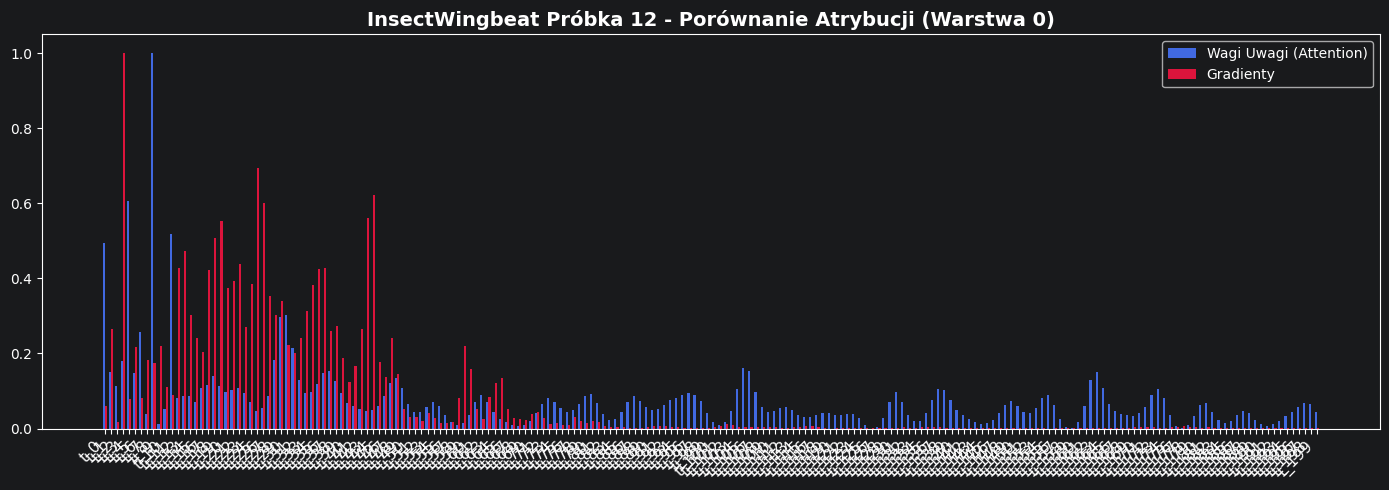

In [20]:
sample_idx = 12
x_sample = X_test_ins[sample_idx]

if isinstance(x_sample, np.ndarray):
    x_tensor = torch.tensor(x_sample, dtype=torch.float32).unsqueeze(0)
else:
    x_tensor = x_sample.clone().detach().to(dtype=torch.float32).unsqueeze(0)

x_tensor.requires_grad_(True)

seq_length = x_tensor.shape[1]
tokens = [f"t_{i}" for i in range(seq_length)]

LAYER_TO_CHECK = 0
print(f"Pobieranie atrybucji dla sygnału o długości {len(tokens)} kroków czasowych z warstwy {LAYER_TO_CHECK}...")

att_attr = get_attention_attribution(model, x_tensor, layer_idx=LAYER_TO_CHECK)
grad_attr = get_gradient_attribution(model, x_tensor, layer_idx=LAYER_TO_CHECK)

visualize_attributions(
    tokens=tokens,
    att_weights=att_attr,
    grad_weights=grad_attr,
    title=f"InsectWingbeat Próbka {sample_idx} - Porównanie Atrybucji (Warstwa {LAYER_TO_CHECK})"
)